## Five Business Questions

1. Which genre of movies is released the most frequently?
2. What is the distribution of movies across voting categories?
3. Which movie achieved the highest popularity and what is its genre?
4. Which movie had the lowest popularity and what is its genre?
5. In which year were the most movies released?

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [5]:
df = pd.read_csv("/content/mymoviedb_tutorial_clean.csv", lineterminator="\n")

print("Shape:", df.shape)
df.head()

Shape: (9827, 9)


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,15-12-2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,01-03-2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,25-02-2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,24-11-2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,22-12-2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [7]:
df["Genre"].head()

,Genre
0,"Action, Adventure, Science Fiction"
1,"Crime, Mystery, Thriller"
2,Thriller
3,"Animation, Comedy, Family, Fantasy"
4,"Action, Adventure, Thriller, War"


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


## Data Preprocessing

The tutorial emphasizes preprocessing as a key part of a data professional's work. The next steps convert the date field, remove columns that are not required for the five questions, verify duplicates, and transform vote averages into readable categories.

In [10]:
df["Release_Date"] = pd.to_datetime(df["Release_Date"], dayfirst=True)

print(df["Release_Date"].dtype)

datetime64[ns]


In [11]:
df["Release_Date"] = df["Release_Date"].dt.year

print(df["Release_Date"].dtype)

int32


In [12]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [13]:
cols = ["Overview", "Original_Language", "Poster_Url"]

df.drop(cols, axis=1, inplace=True)

df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [14]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


## Creating Voting Categories

Using the descriptive statistics of `Vote_Average`, the scores are divided into four percentile-based groups.

In [15]:
def categorize_col(df, col, labels):
    edges = [df[col].describe()["min"],
             df[col].describe()["25%"],
             df[col].describe()["50%"],
             df[col].describe()["75%"],
             df[col].describe()["max"]]

    df[col] = pd.cut(df[col], edges, labels=labels, duplicates="drop")

    return df

In [16]:
labels = ["non_popular", "below_avg", "average", "popular"]

df = categorize_col(df, "Vote_Average", labels)

df["Vote_Average"].unique()

['popular', 'below_avg', 'average', 'non_popular', NaN]
Categories (4, object): ['non_popular' < 'below_avg' < 'average' < 'popular']

In [17]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [18]:
df["Vote_Average"].value_counts()

,count
Vote_Average,
non_popular,2467
popular,2450
average,2412
below_avg,2398


In [19]:
df.dropna(inplace=True)

df.isna().sum()

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0


In [20]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


## Splitting Multiple Genres

A movie can belong to several genres. The tutorial splits the comma-separated genre string and then explodes the list so each genre becomes its own row.

In [21]:
df["Genre"] = df["Genre"].str.split(",")

df = df.explode("Genre").reset_index(drop=True)

df["Genre"] = df["Genre"].str.strip()

df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [22]:
df["Genre"] = df["Genre"].astype("category")
df["Genre"].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


In [24]:
df.nunique()

,0
Release_Date,100
Title,9415
Popularity,8088
Vote_Count,3265
Vote_Average,4
Genre,19


In [25]:
print("Rows before genre explosion: 9,827")
print("Rows after genre explosion:", len(df))

Rows before genre explosion: 9,827
Rows after genre explosion: 25552


# Data Visualization

The visual analysis below answers the five assignment questions.

In [26]:
sns.set_style("whitegrid")

## Question 1 — What is the most frequent genre?

In [27]:
df["Genre"].describe()

,Genre
count,25552
unique,19
top,Drama
freq,3715


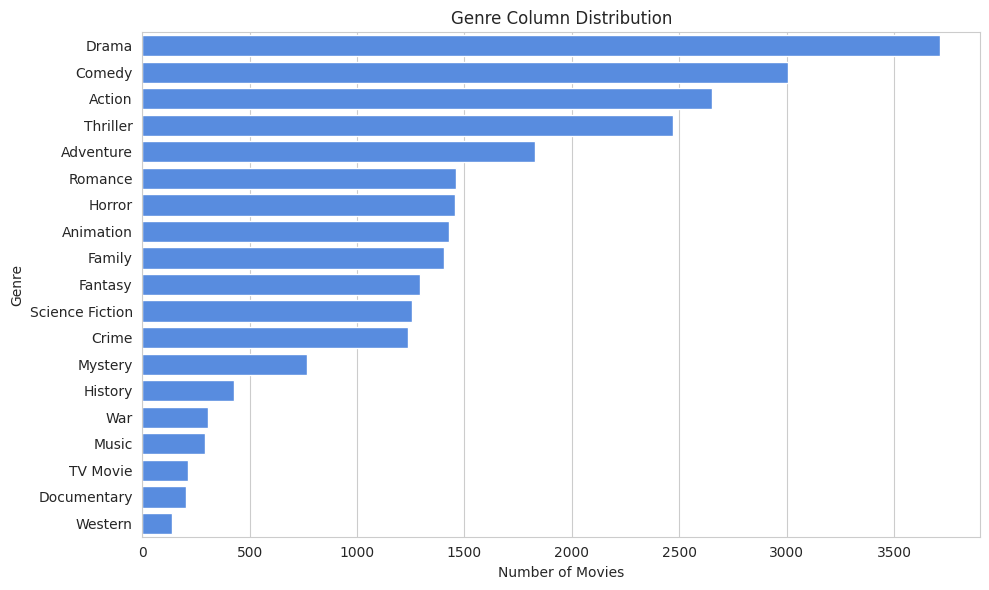

Most frequent genre: Drama
Number of records: 3715


In [28]:
genre_counts = df["Genre"].value_counts()

plt.figure(figsize=(10, 6))
sns.countplot(y="Genre", data=df, order=genre_counts.index, color="#4287f5")
plt.title("Genre Column Distribution")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

print("Most frequent genre:", genre_counts.idxmax())
print("Number of records:", genre_counts.max())

## Question 2 — What is the voting-category distribution?

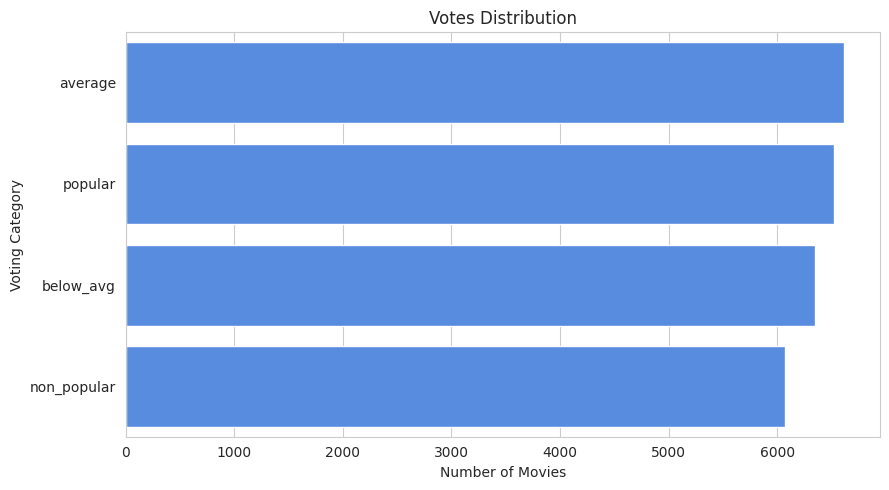

Vote_Average
average        6613
popular        6520
below_avg      6348
non_popular    6071
Name: count, dtype: int64


In [29]:
vote_counts = df["Vote_Average"].value_counts()

plt.figure(figsize=(9, 5))
sns.countplot(y="Vote_Average", data=df, order=vote_counts.index, color="#4287f5")
plt.title("Votes Distribution")
plt.xlabel("Number of Movies")
plt.ylabel("Voting Category")
plt.tight_layout()
plt.show()

print(vote_counts)

## Question 3 — Which movie has the highest popularity?

In [30]:
highest_popularity = df[df["Popularity"] == df["Popularity"].max()]

highest_popularity[["Title", "Popularity", "Genre"]]

,Title,Popularity,Genre
0,Spider-Man: No Way Home,5083.954,Action
1,Spider-Man: No Way Home,5083.954,Adventure
2,Spider-Man: No Way Home,5083.954,Science Fiction


## Question 4 — Which movie has the lowest popularity?

In [31]:
lowest_popularity = df[df["Popularity"] == df["Popularity"].min()]

lowest_popularity[["Title", "Popularity", "Genre"]]

,Title,Popularity,Genre
25546,The United States vs. Billie Holiday,13.354,Music
25547,The United States vs. Billie Holiday,13.354,Drama
25548,The United States vs. Billie Holiday,13.354,History
25549,Threads,13.354,War
25550,Threads,13.354,Drama
25551,Threads,13.354,Science Fiction


## Question 5 — In which year were the most movies released?

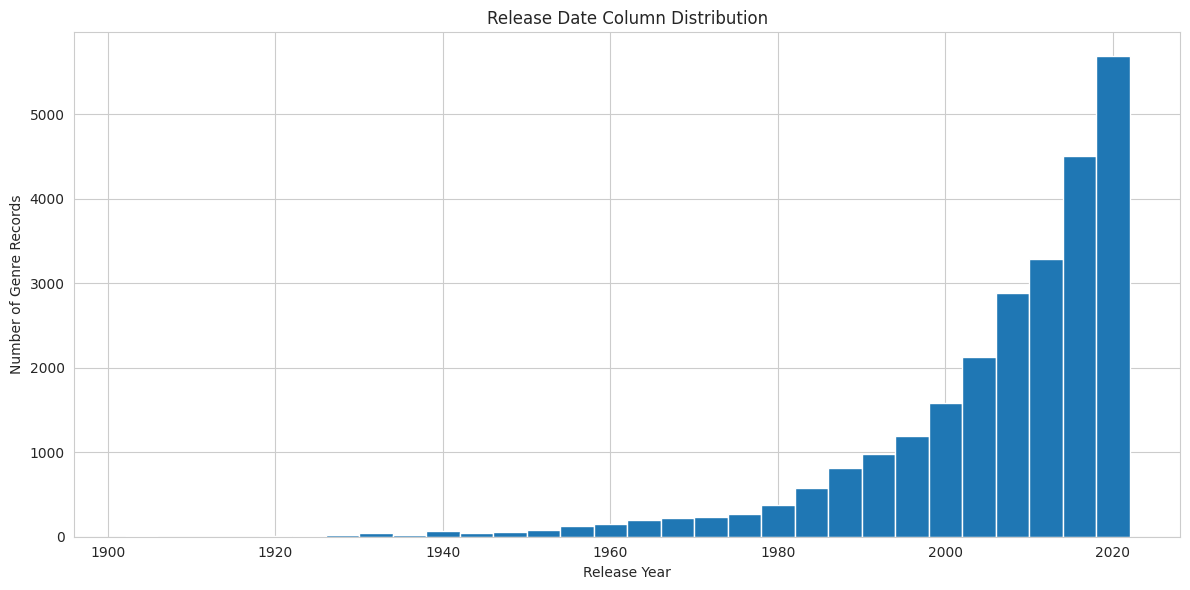

Peak year: 2021
Movie/genre records in peak year: 1636


In [32]:
year_counts = df["Release_Date"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
df["Release_Date"].hist(bins=30)
plt.title("Release Date Column Distribution")
plt.xlabel("Release Year")
plt.ylabel("Number of Genre Records")
plt.tight_layout()
plt.show()

print("Peak year:", df["Release_Date"].value_counts().idxmax())
print("Movie/genre records in peak year:", df["Release_Date"].value_counts().max())

## Final Answers

The values below are generated directly from the uploaded dataset after applying the tutorial's preprocessing workflow. The tutorial summary supplied with this project reports 2020 as the peak year, but the uploaded dataset produces 2021 when the same release-year logic is run. The notebook therefore reports the result of the actual supplied data rather than silently changing it to match the summary.

In [33]:
answer_table = pd.DataFrame({
    "Question": [
        "Most frequent genre",
        "Largest voting category",
        "Highest popularity movie",
        "Lowest popularity movie",
        "Peak release year"
    ],
    "Answer": [
        genre_counts.idxmax(),
        vote_counts.idxmax(),
        df.loc[df["Popularity"].idxmax(), "Title"],
        ", ".join(lowest_popularity["Title"].drop_duplicates().tolist()),
        int(df["Release_Date"].value_counts().idxmax())
    ]
})
answer_table

,Question,Answer
0,Most frequent genre,Drama
1,Largest voting category,average
2,Highest popularity movie,Spider-Man: No Way Home
3,Lowest popularity movie,"The United States vs. Billie Holiday, Threads"
4,Peak release year,2021
